In [53]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict

In [54]:
class BMIState(TypedDict):

    height_m: float
    weight_kg: float
    bmi: float
    category: str
    

In [55]:
def calculate_Bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)
    state['bmi'] = round(bmi,2) 

    return state

In [56]:
def label_Bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5: 
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "obese"
    
    return state

In [57]:
# Define graph
graph = StateGraph(BMIState)

#create Node
graph.add_node('Calculator_BMI', calculate_Bmi)
graph.add_node('label_BMI', label_Bmi)

#Add edges
graph.add_edge(START,'Calculator_BMI')
graph.add_edge('Calculator_BMI','label_BMI')
graph.add_edge('label_BMI',END)

#compile
worklow = graph.compile()

In [58]:
# Invoke
initial_state = {'height_m': 1.54, 'weight_kg': 80}
final_state = worklow.invoke(initial_state)

print(final_state)

{'height_m': 1.54, 'weight_kg': 80, 'bmi': 33.73, 'category': 'obese'}


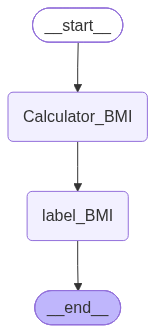

In [59]:
from IPython.display import Image, display
display(Image(worklow.get_graph().draw_mermaid_png()))